In [38]:
#Importing relevant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
#Create a dataframe
df = pd.read_csv('House Price.csv')

In [40]:
#Finallzing dependant Variables
IV = input(
    "The available options are: Id, LotFrontage, LotArea, Alley, MasVnrArea, "
    "1stFlrSF, 2ndFlrSF, GrLivArea, GarageType, GarageArea, SalePrice.\n"
    "Key in one of the inputs (Case sensitive): "
)
position_IV = df.columns.get_loc(IV)

In [41]:
IV

'SalePrice'

In [42]:
#Key data analysis
len(df)
df.head()
df.isnull().any()
df.isnull().sum()

Id                0
LotFrontage     259
LotArea           0
Alley          1369
MasVnrArea        8
1stFlrSF          0
2ndFlrSF          0
GrLivArea         0
GarageType       81
GarageArea        0
SalePrice         0
dtype: int64

In [43]:
# Check for missing values, percent missing, and unique counts including NaN

FileNameDesc = pd.DataFrame({
    'column_name': df.columns,
    'missing_count': df.isnull().sum().values,
    'percent_missing': (df.isnull().sum().values / len(df)) * 100,
    'unique_count': df.nunique(dropna=False).values
})


In [44]:
FileNameDesc

,column_name,missing_count,percent_missing,unique_count
0,Id,0,0.000000,1460
1,LotFrontage,259,17.739726,111
2,LotArea,0,0.000000,1073
3,Alley,1369,93.767123,3
4,MasVnrArea,8,0.547945,328
5,1stFlrSF,0,0.000000,753
6,2ndFlrSF,0,0.000000,417
7,GrLivArea,0,0.000000,861
8,GarageType,81,5.547945,7
9,GarageArea,0,0.000000,441


In [45]:
File_Col_Type = (df.dtypes).reset_index()

In [46]:
#merging Column Type with other information about dataset
FileNameDesc = FileNameDesc.merge(File_Col_Type, left_on = 'column_name', right_on = 'index', how = 'inner')

In [47]:
del FileNameDesc['index']
FileNameDesc = FileNameDesc.rename(index=str, columns = {0:"column_type"})

In [48]:
FileNameDesc

,column_name,missing_count,percent_missing,unique_count,column_type
0,Id,0,0.000000,1460,int64
1,LotFrontage,259,17.739726,111,float64
2,LotArea,0,0.000000,1073,int64
3,Alley,1369,93.767123,3,str
4,MasVnrArea,8,0.547945,328,float64
5,1stFlrSF,0,0.000000,753,int64
6,2ndFlrSF,0,0.000000,417,int64
7,GrLivArea,0,0.000000,861,int64
8,GarageType,81,5.547945,7,str
9,GarageArea,0,0.000000,441,int64


In [49]:
#Drop column with more than 25% null values
df.drop(['Alley'], axis = 1, inplace = True)

In [50]:
#Add IQR(Outlier's)
def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1
    fence_low = q1 - 1.5*iqr
    fence_high = q3 + 1.5*iqr
    df_out = df_in.loc[(df_in[col_name]> fence_low) & (df_in[col_name] < fence_high)]
    return df_out

In [51]:
df_col=FileNameDesc[(FileNameDesc.column_type=='int64') | (FileNameDesc.column_type =='float64')]

In [52]:
for col_na in df_col['column_name']:
    if col_na != IV:
        remove_outlier(df,col_na)

In [53]:
#Apply Mode strategy to populate the categorical data
df.groupby('GarageType').agg({'GarageType': np.size})
df["GarageType"]=df["GarageType"].fillna('Attchd')
df["GarageType"] = df["GarageType"].astype('category')
df["GarageType"] = df["GarageType"].cat.codes

In [54]:
#Mean strategy to populate the quantitative variable
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].mean())
df["LotFrontage"]

0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64

In [55]:
#Median strategy to populate the quantitative variable
df["MasVnrArea"] = df["MasVnrArea"].fillna(df["MasVnrArea"].median())
df["MasVnrArea"]

0       196.0
1         0.0
2       162.0
3         0.0
4       350.0
        ...  
1455      0.0
1456    119.0
1457      0.0
1458      0.0
1459      0.0
Name: MasVnrArea, Length: 1460, dtype: float64

In [56]:
df = pd.get_dummies(df, columns=['GarageType'], drop_first=True)

In [57]:
df1=df['SalePrice']

In [58]:
df.drop(['SalePrice'], axis = 1, inplace = True)

In [59]:
df=pd.concat([df,df1],axis=1)

In [60]:
#Key data analysis
len(df)
df.head()
df.isnull().any()
df.isnull().sum()

Id              0
LotFrontage     0
LotArea         0
MasVnrArea      0
1stFlrSF        0
2ndFlrSF        0
GrLivArea       0
GarageArea      0
GarageType_1    0
GarageType_2    0
GarageType_3    0
GarageType_4    0
GarageType_5    0
SalePrice       0
dtype: int64

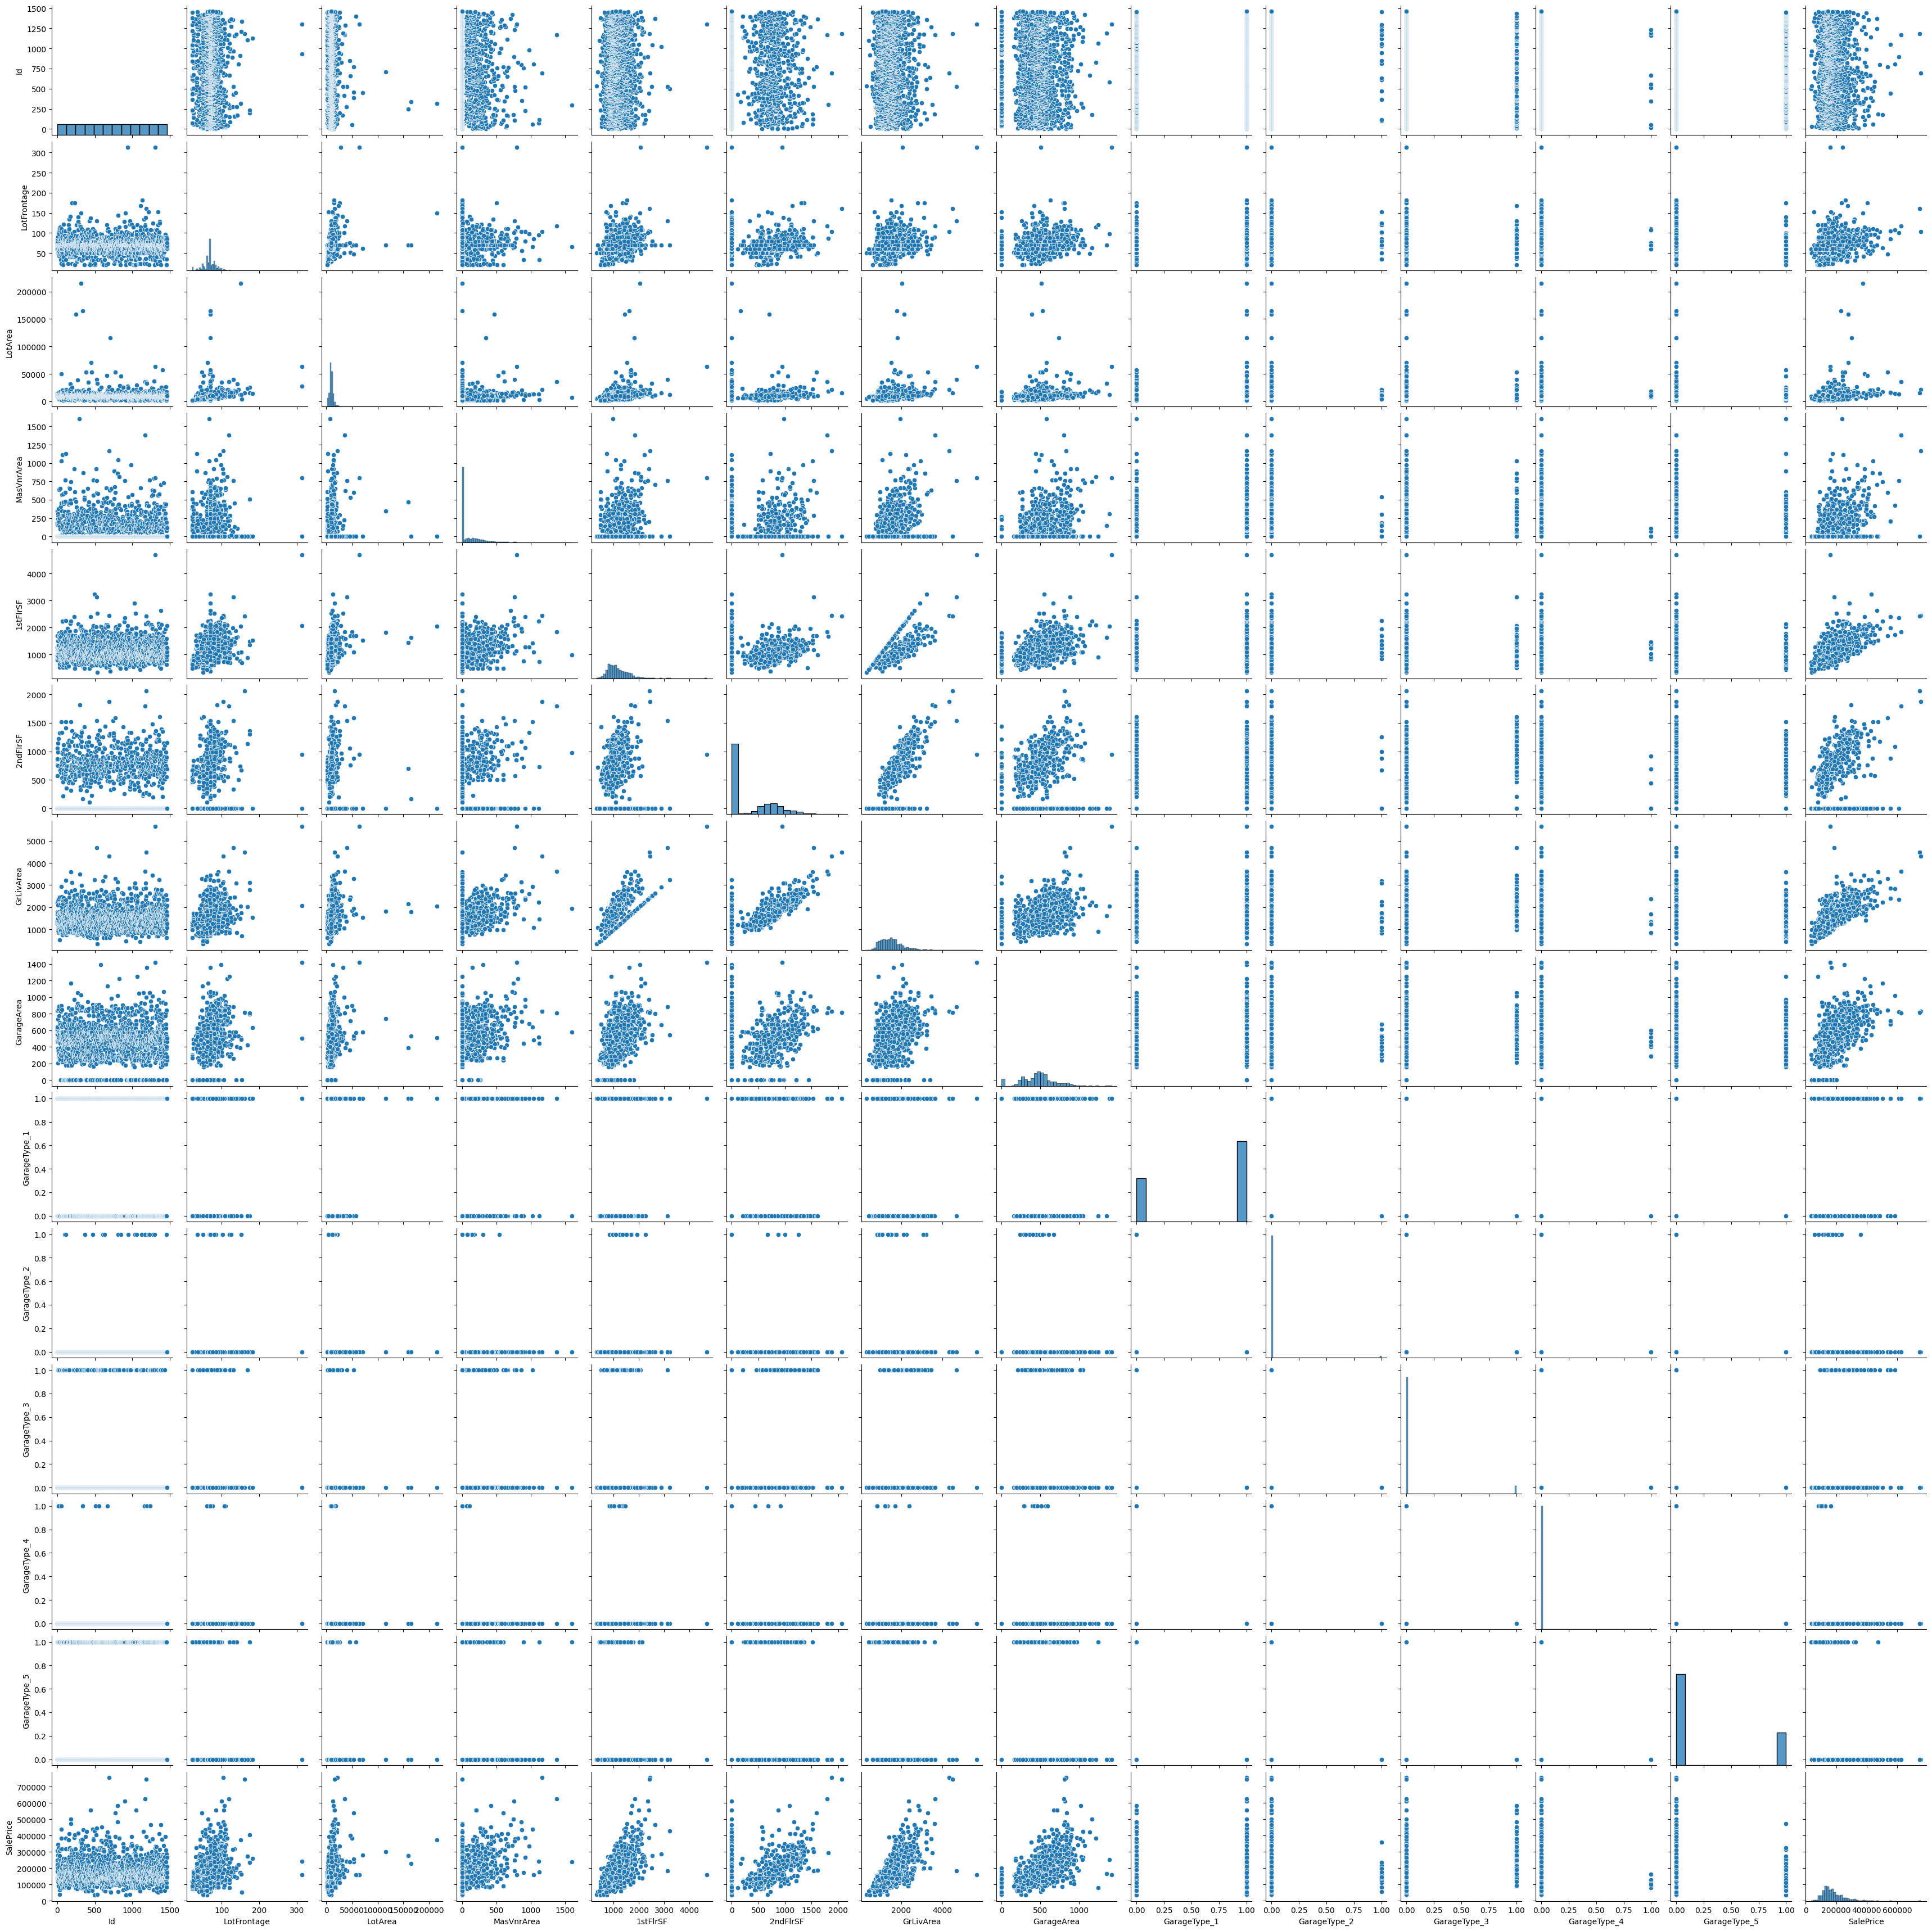

In [61]:
#Analyse the selected variables 
sns.pairplot(df)

<Axes: >

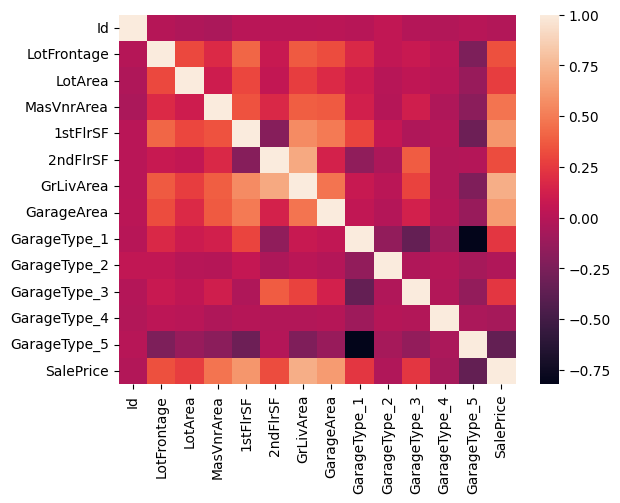

In [62]:
df.corr()
sns.heatmap(df.corr(),annot=False)

In [63]:
x = df.iloc[:,1:13]
y = df.iloc[:,13:]

In [64]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 100) 

In [65]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm = lm.fit(x_train,y_train)   #lm.fit(input,output)

In [66]:
lm.coef_

array([[-1.89195406e+02,  2.92488563e-01,  5.77934108e+01,
         9.31370291e+01,  6.58204127e+01, -8.60850226e+00,
         1.17301334e+02,  1.09608841e+05,  8.00334258e+04,
         1.17818148e+05,  4.44584210e+04,  7.70242422e+04]])

In [67]:
coefficients = pd.concat([pd.DataFrame(x_train.columns),pd.DataFrame(np.transpose(lm.coef_))], axis = 1)

In [68]:
lm.intercept_

array([-89484.77986411])

In [69]:
y_pred = lm.predict(x_test)

In [70]:
y_error = y_test - y_pred

In [71]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7252823600649492

In [72]:
import statsmodels.api as sma
x_train = sma.add_constant(x_train) ## let's add an intercept (beta_0) to our model
x_test = sma.add_constant(x_test) 

In [78]:
import statsmodels.api as sm

# Convert x_train to DataFrame if needed
X_ols = x_train.copy() if isinstance(x_train, pd.DataFrame) else pd.DataFrame(x_train)

# Convert y_train to Series
if isinstance(y_train, pd.DataFrame):
    y_ols = y_train.iloc[:, 0].copy()
elif isinstance(y_train, pd.Series):
    y_ols = y_train.copy()
else:
    y_ols = pd.Series(np.ravel(y_train), index=X_ols.index)

# Make sure indexes match
if len(y_ols) == len(X_ols):
    y_ols.index = X_ols.index

# Convert categorical/object columns into dummy variables
X_ols = pd.get_dummies(X_ols, drop_first=True, dtype=float)

# Convert all remaining values to numeric
X_ols = X_ols.apply(pd.to_numeric, errors='coerce')
y_ols = pd.to_numeric(y_ols, errors='coerce')

# Remove rows with missing or invalid values
mask = X_ols.notnull().all(axis=1) & y_ols.notnull()
X_ols = X_ols.loc[mask].astype(float)
y_ols = y_ols.loc[mask].astype(float)

# Add intercept/constant
X_ols = sm.add_constant(X_ols, has_constant='add')

# Fit OLS model
lm2 = sm.OLS(y_ols, X_ols).fit()

# Show summary
print(lm2.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     204.5
Date:                Thu, 30 Apr 2026   Prob (F-statistic):          1.46e-275
Time:                        09:14:49   Log-Likelihood:                -14167.
No. Observations:                1168   AIC:                         2.836e+04
Df Residuals:                    1155   BIC:                         2.843e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -4.474e+04   1.18e+04     -3.791   

In [80]:
x_test_const = sm.add_constant(x_test, has_constant='add')

y_pred2 = lm2.predict(x_test_const)

In [81]:
import numpy as np
y_test = pd.to_numeric(y_test.SalePrice, errors='coerce')
RSS = np.sum((y_pred2 - y_test)**2)
y_mean = np.mean(y_test)
TSS = np.sum((y_test - y_mean)**2)
R2 = 1 - RSS/TSS
R2

n=x_test.shape[0]
p=x_test.shape[1] - 1

adj_rsquared = 1 - (1 - R2) * ((n - 1)/(n-p-1))
adj_rsquared

np.float64(0.7134665475950079)

In [90]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


def prepare_vif_data(x):
    # Make a copy of x_train
    X_vif = x.copy() if isinstance(x, pd.DataFrame) else pd.DataFrame(x)

    # Convert categorical/object columns into dummy variables
    X_vif = pd.get_dummies(X_vif, drop_first=True, dtype=float)

    # Convert all columns to numeric
    X_vif = X_vif.apply(pd.to_numeric, errors='coerce')

    # Replace infinite values with NaN
    X_vif = X_vif.replace([np.inf, -np.inf], np.nan)

    # Drop rows with missing values
    X_vif = X_vif.dropna()

    # Drop columns with only one unique value
    X_vif = X_vif.loc[:, X_vif.nunique() > 1]

    # Convert everything to float
    X_vif = X_vif.astype(float)

    return X_vif


# Prepare x_train for VIF
X_vif = prepare_vif_data(x_train)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data

,feature,VIF
0,LotFrontage,15.696737
1,LotArea,2.516498
2,MasVnrArea,1.663869
3,1stFlrSF,719.991554
4,2ndFlrSF,145.299014
5,GrLivArea,1165.948790
6,GarageArea,9.088083
7,GarageType_1,12.564521
8,GarageType_2,1.268867
9,GarageType_3,2.437945


In [ ]:
def calculate_vif(x, thresh=5.0):
    output = prepare_vif_data(x)

    dropped_columns = []

    while True:
        vif = pd.Series(
            [variance_inflation_factor(output.values, i) for i in range(output.shape[1])],
            index=output.columns
        )

        max_vif = vif.max()
        max_vif_column = vif.idxmax()

        print("Current VIF values:")
        print(vif)
        print("\nMax VIF:", max_vif)
        print("Variable with Max VIF:", max_vif_column)
        print("-" * 50)

        if max_vif <= thresh:
            break

        dropped_columns.append(max_vif_column)
        output = output.drop(columns=[max_vif_column])

        if output.shape[1] <= 1:
            break

    print("Dropped columns due to high VIF:")
    print(dropped_columns)

    return output



Current VIF values:
LotFrontage       15.696737
LotArea            2.516498
MasVnrArea         1.663869
1stFlrSF         719.991554
2ndFlrSF         145.299014
GrLivArea       1165.948790
GarageArea         9.088083
GarageType_1      12.564521
GarageType_2       1.268867
GarageType_3       2.437945
GarageType_4       1.114611
GarageType_5       4.395300
dtype: float64

Max VIF: 1165.9487895886289
Variable with Max VIF: GrLivArea
--------------------------------------------------
Current VIF values:
LotFrontage     15.620497
LotArea          2.515540
MasVnrArea       1.659536
1stFlrSF        18.992307
2ndFlrSF         2.240573
GarageArea       8.923176
GarageType_1    12.554536
GarageType_2     1.267790
GarageType_3     2.433167
GarageType_4     1.114242
GarageType_5     4.393459
dtype: float64

Max VIF: 18.992307379197022
Variable with Max VIF: 1stFlrSF
--------------------------------------------------
Current VIF values:
LotFrontage     14.631255
LotArea          2.428553
MasVnrArea 

,LotArea,MasVnrArea,2ndFlrSF,GarageType_1,GarageType_2,GarageType_3,GarageType_4,GarageType_5
133,6853.0,136.0,0.0,1.0,0.0,0.0,0.0,0.0
290,15611.0,0.0,840.0,1.0,0.0,0.0,0.0,0.0
24,8246.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1093,9230.0,166.0,0.0,0.0,0.0,0.0,0.0,1.0
1288,5664.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
802,8199.0,0.0,728.0,1.0,0.0,0.0,0.0,0.0
53,50271.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
350,7820.0,362.0,0.0,1.0,0.0,0.0,0.0,0.0
79,10440.0,0.0,548.0,0.0,0.0,0.0,0.0,1.0


In [92]:
train_out = calculate_vif(x_train)

train_out.head()

Current VIF values:
LotFrontage       15.696737
LotArea            2.516498
MasVnrArea         1.663869
1stFlrSF         719.991554
2ndFlrSF         145.299014
GrLivArea       1165.948790
GarageArea         9.088083
GarageType_1      12.564521
GarageType_2       1.268867
GarageType_3       2.437945
GarageType_4       1.114611
GarageType_5       4.395300
dtype: float64

Max VIF: 1165.9487895886289
Variable with Max VIF: GrLivArea
--------------------------------------------------
Current VIF values:
LotFrontage     15.620497
LotArea          2.515540
MasVnrArea       1.659536
1stFlrSF        18.992307
2ndFlrSF         2.240573
GarageArea       8.923176
GarageType_1    12.554536
GarageType_2     1.267790
GarageType_3     2.433167
GarageType_4     1.114242
GarageType_5     4.393459
dtype: float64

Max VIF: 18.992307379197022
Variable with Max VIF: 1stFlrSF
--------------------------------------------------
Current VIF values:
LotFrontage     14.631255
LotArea          2.428553
MasVnrArea 

,LotArea,MasVnrArea,2ndFlrSF,GarageType_1,GarageType_2,GarageType_3,GarageType_4,GarageType_5
133,6853.0,136.0,0.0,1.0,0.0,0.0,0.0,0.0
290,15611.0,0.0,840.0,1.0,0.0,0.0,0.0,0.0
24,8246.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1093,9230.0,166.0,0.0,0.0,0.0,0.0,0.0,1.0
1288,5664.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [95]:
# Check columns before dropping
print(x_test.columns)

# Columns you want to drop
columns_to_drop = ["LotFrontage", "1stFlrSF", "GrLivArea", "GarageArea"]

# Drop only if they exist
x_test = x_test.drop(columns=columns_to_drop, errors="ignore")

# Check result
x_test.head()

Index(['const', 'LotArea', 'MasVnrArea', '2ndFlrSF', 'GarageType_1',
       'GarageType_2', 'GarageType_3', 'GarageType_4', 'GarageType_5'],
      dtype='str')


,const,LotArea,MasVnrArea,2ndFlrSF,GarageType_1,GarageType_2,GarageType_3,GarageType_4,GarageType_5
1436,1.0,9000,0.0,0,False,False,False,False,True
57,1.0,11645,0.0,860,True,False,False,False,False
780,1.0,7875,38.0,0,True,False,False,False,False
382,1.0,9245,0.0,858,True,False,False,False,False
1170,1.0,9880,0.0,0,True,False,False,False,False


In [100]:
# Prepare X
X_train_ols = train_out.copy()

# Convert X to numeric
X_train_ols = X_train_ols.apply(pd.to_numeric, errors='coerce')
X_train_ols = X_train_ols.replace([np.inf, -np.inf], np.nan)

# Prepare y as 1-dimensional
if isinstance(y_train, pd.Series):
    y_train_ols = y_train.copy()
elif isinstance(y_train, pd.DataFrame):
    y_train_ols = y_train.iloc[:, 0].copy()
else:
    y_train_ols = pd.Series(np.ravel(y_train))

# Match indexes if lengths are same
if len(y_train_ols) == len(X_train_ols):
    y_train_ols.index = X_train_ols.index

# Combine X and y, then remove missing rows
model_data = pd.concat([y_train_ols.rename("target"), X_train_ols], axis=1)
model_data = model_data.dropna()

# Split back into y and X
y_train_ols = model_data["target"].astype(float)
X_train_ols = model_data.drop(columns=["target"]).astype(float)

# Add intercept/constant
X_train_ols = sm.add_constant(X_train_ols, has_constant='add')

# Fit OLS model
lm2 = sm.OLS(y_train_ols, X_train_ols).fit()

# Show summary
lm2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.405
Model:                            OLS   Adj. R-squared:                  0.401
Method:                 Least Squares   F-statistic:                     98.59
Date:                Thu, 30 Apr 2026   Prob (F-statistic):          4.98e-125
Time:                        09:58:41   Log-Likelihood:                -14529.
No. Observations:                1168   AIC:                         2.908e+04
Df Residuals:                    1159   BIC:                         2.912e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         5.155e+04   1.54e+04      3.345      0.001    2.13e+04    8.18e+04
const         5.155e+04   1.54e+04      3.345      0.001    2.13e+04    8.18e+04
LotArea          1.4221      0.185      7.697      0.000       1.060       1.785
MasVnrArea     160.4163     10.088     15.902      0.000     140.624     180.208
2ndFlrSF        39.0668      4.510      8.663      0.000      30.219      47.915
GarageType_1    4.7e+04   3.08e+04      1.527      0.127   -1.34e+04    1.07e+05
GarageType_2  1.591e+04   3.45e+04      0.461      0.645   -5.18e+04    8.37e+04
GarageType_3  5.496e+04   3.17e+04      1.733      0.083   -7262.212    1.17e+05
GarageType_4 -2.119e+04   3.85e+04     -0.551      0.582   -9.67e+04    5.43e+04
GarageType_5 -4522.0716   3.09e+04     -0.146      0.884   -6.52e+04    5.61e+04
==============================================================================
Omnibus:                      418.867   Durbin-Watson:                   2.010
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2987.986
Skew:                           1.471   Prob(JB):                         0.00
Kurtosis:                      10.262   Cond. No.                     3.39e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 2.1e-26. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [101]:
#Autocorrelation Test
from statsmodels.stats import diagnostic as diag
diag.acorr_ljungbox(lm2.resid , lags = 1) 

,lb_stat,lb_pvalue
1,0.042025,0.837572


In [102]:
#Heteroscedasticity test
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
name = ['F statistic', 'p-value']
test = sms.het_goldfeldquandt(lm2.resid, lm2.model.exog)
lzip(name, test)

[('F statistic', np.float64(0.8311697551342259)),
 ('p-value', np.float64(0.9866058476793199))]